<a href="https://colab.research.google.com/github/RabeeaAnjum/Battery-Health-Prediction-and-Remaining-Useful-Life-RUL-Estimation-Using-Machine-Learning/blob/main/CEP_DM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# BATTERY HEALTH PREDICTION USING MACHINE LEARNING
# ============================================================
# Author: Rabeea Anjum
# Project Type: Multi-Output Regression
# Dataset: Lithium-Ion Battery Dataset
# ============================================================

STEP 1 — IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

STEP 2 — LOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Battery_dataset.csv to Battery_dataset.csv


In [ ]:
df = pd.read_csv('Battery_dataset.csv')

STEP 3 — BASIC DATASET INFORMATION

In [ ]:
print("FIRST 5 ROWS")
df.head()

FIRST 5 ROWS


,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


In [ ]:
print("DATASET SHAPE")
print(df.shape)

DATASET SHAPE
(680, 11)


In [ ]:
print("COLUMN NAMES")
print(df.columns)

COLUMN NAMES
Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL'],
      dtype='object')


In [ ]:
print("DATASET INFO")
print(df.info())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   battery_id  680 non-null    object 
 1   cycle       680 non-null    int64  
 2   chI         680 non-null    float64
 3   chV         680 non-null    float64
 4   chT         680 non-null    float64
 5   disI        680 non-null    float64
 6   disV        680 non-null    float64
 7   disT        680 non-null    float64
 8   BCt         680 non-null    float64
 9   SOH         680 non-null    float64
 10  RUL         680 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 58.6+ KB
None


In [ ]:
print("STATISTICAL SUMMARY")
print(df.describe())

STATISTICAL SUMMARY
            cycle         chI         chV         chT        disI        disV  \
count  680.000000  680.000000  680.000000  680.000000  680.000000  680.000000   
mean   114.470588    1.400069    4.202765   26.871113    2.007630    3.501070   
std     66.601594    0.102903    0.046973    1.489824    0.097797    0.304160   
min      1.000000    1.000859    4.035078   21.604784    1.702438    2.484857   
25%     57.000000    1.333381    4.170685   25.822944    1.945474    3.299257   
50%    114.000000    1.401904    4.202503   26.823350    2.006990    3.496967   
75%    170.250000    1.469383    4.235014   27.944619    2.066924    3.718415   
max    250.000000    1.747515    4.359233   30.913077    2.411226    4.363548   

             disT         BCt         SOH         RUL  
count  680.000000  680.000000  680.000000  680.000000  
mean    33.099894    1.427851   71.392565  113.470588  
std      1.827415    0.333250   16.662488   66.601594  
min     26.848457    0.750

STEP 4 — CHECK MISSING VALUES

In [ ]:
print(df.isnull().sum())

battery_id    0
cycle         0
chI           0
chV           0
chT           0
disI          0
disV          0
disT          0
BCt           0
SOH           0
RUL           0
dtype: int64


STEP 5 — ENCODE BATTERY ID

In [ ]:
encoder = LabelEncoder()
df['battery_id'] = encoder.fit_transform(df['battery_id'])
print("ENCODED BATTERY IDs")
print(df['battery_id'].unique())

ENCODED BATTERY IDs
[0 1 2]


STEP 6 — EXPLORATORY DATA ANALYSIS (EDA)

6.1 CORRELATION HEATMAP

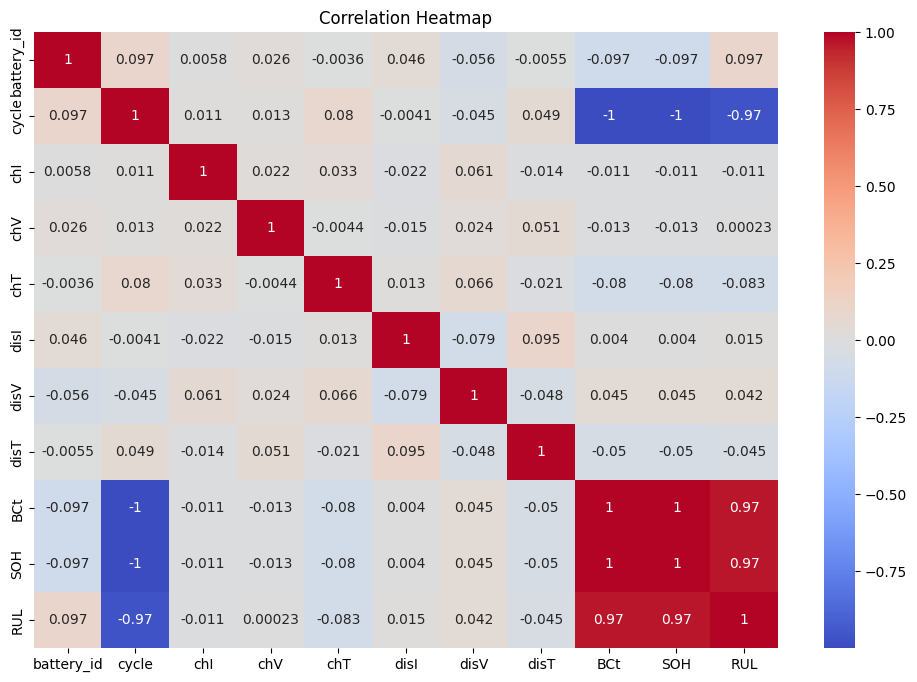

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

6.2 CYCLE VS SOH

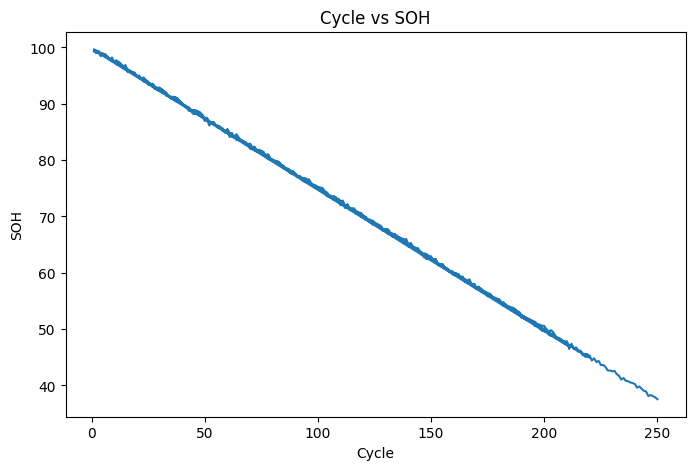

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df['cycle'], df['SOH'])
plt.xlabel("Cycle")
plt.ylabel("SOH")
plt.title("Cycle vs SOH")
plt.show()

6.3 CYCLE VS RUL

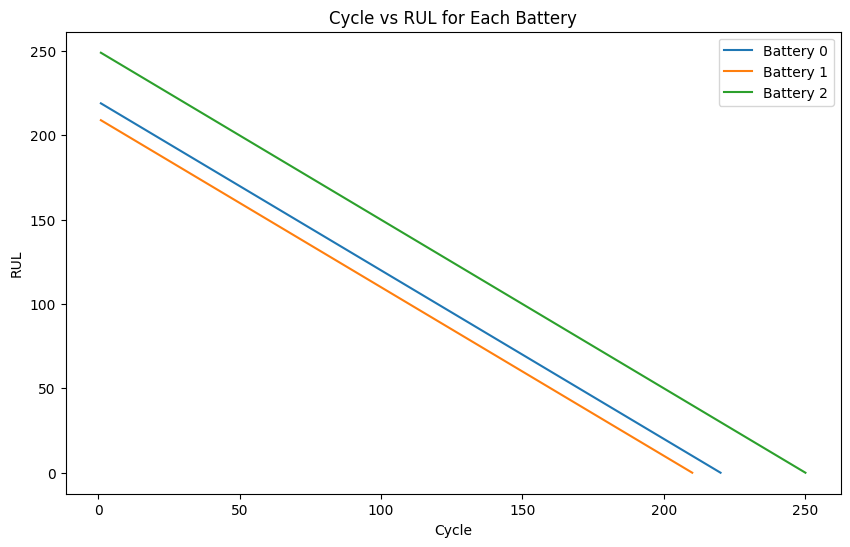

In [ ]:
plt.figure(figsize=(10,6))

for battery in df['battery_id'].unique():

    subset = df[df['battery_id'] == battery]

    plt.plot(
        subset['cycle'],
        subset['RUL'],
        label=f'Battery {battery}'
    )

plt.xlabel("Cycle")
plt.ylabel("RUL")

plt.title("Cycle vs RUL for Each Battery")

plt.legend()

plt.show()

6.4 CHARGING TEMPERATURE VS SOH

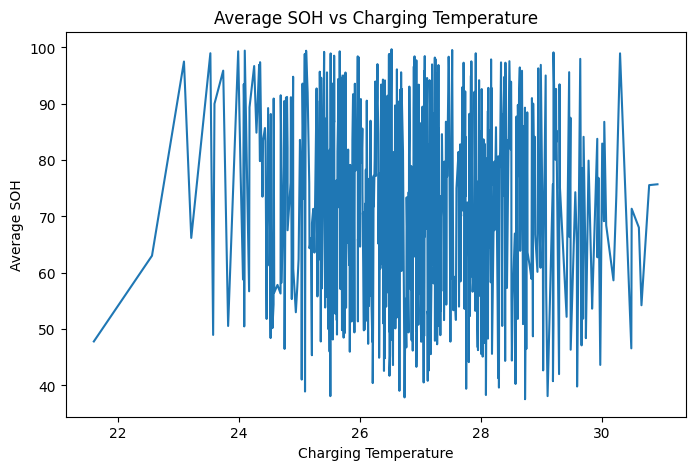

In [ ]:
temp_soh = df.groupby('chT')['SOH'].mean()

plt.figure(figsize=(8,5))

plt.plot(temp_soh.index, temp_soh.values)

plt.xlabel("Charging Temperature")
plt.ylabel("Average SOH")

plt.title("Average SOH vs Charging Temperature")

plt.show()

6.5 BATTERY TYPE COMPARISON

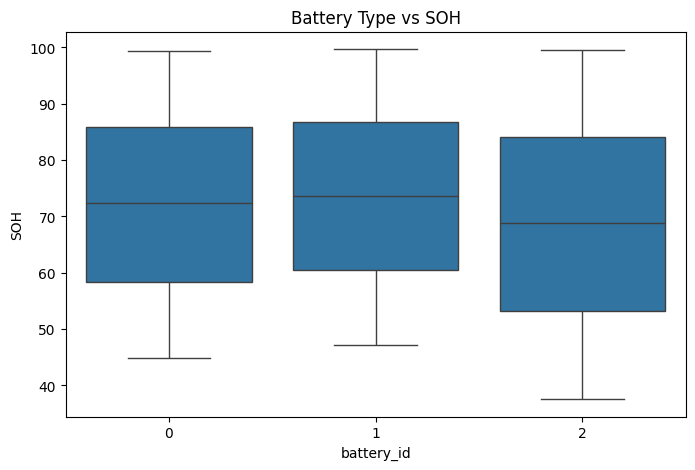

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='battery_id', y='SOH', data=df)
plt.title("Battery Type vs SOH")
plt.show()

STEP 7 — OUTLIER DETECTION

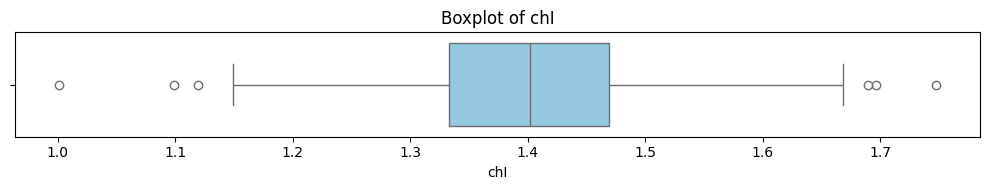

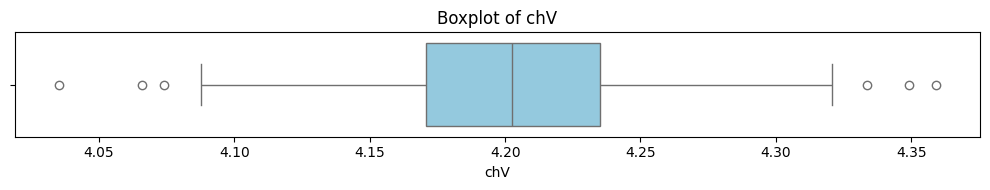

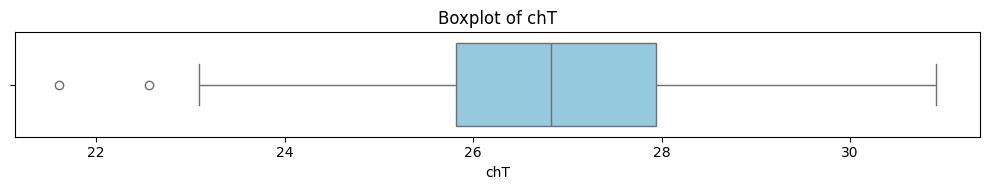

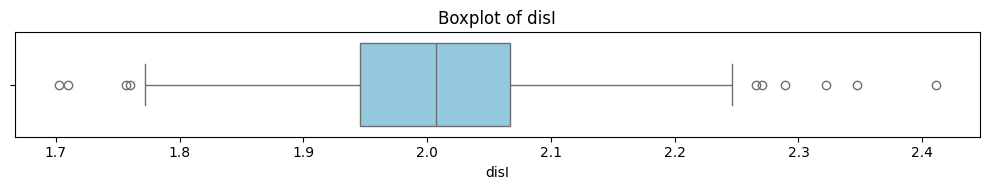

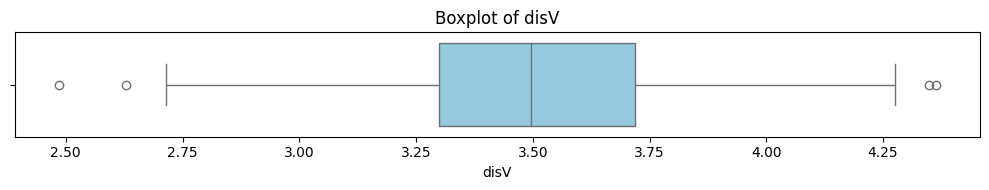

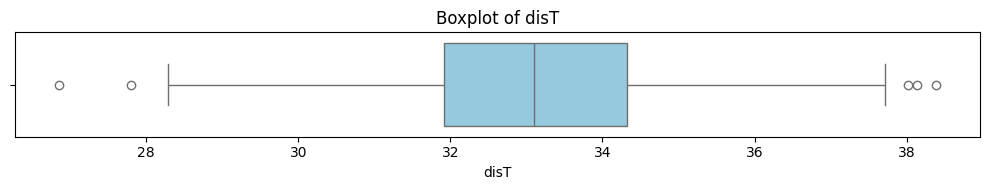

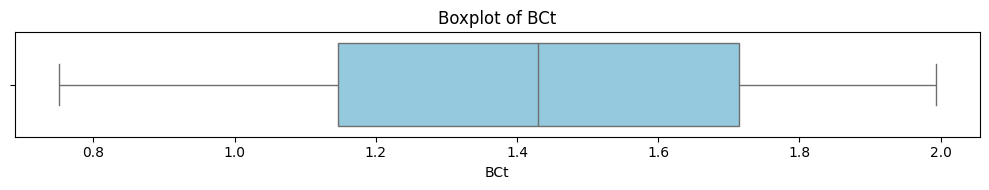

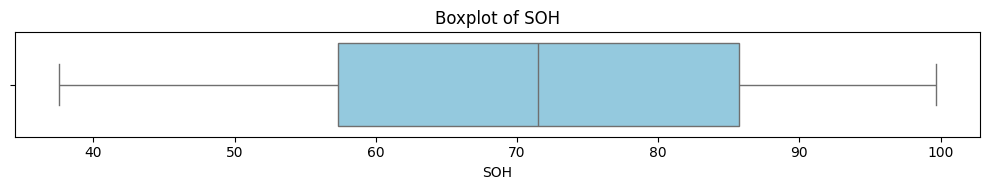

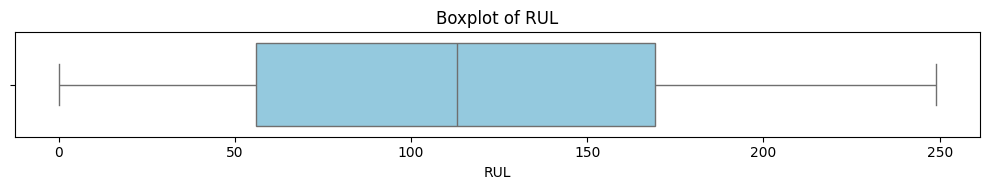

In [ ]:
# BOXPLOTS
numerical_columns = [
    'chI',
    'chV',
    'chT',
    'disI',
    'disV',
    'disT',
    'BCt',
    'SOH',
    'RUL'
]
for col in numerical_columns:
    plt.figure(figsize=(10,2))
    sns.boxplot(
        x=df[col],
        color='skyblue'
    )
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [ ]:
print("OUTLIER DETECTION USING IQR")
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} --> Outliers: {len(outliers)}")

OUTLIER DETECTION USING IQR
chI --> Outliers: 6
chV --> Outliers: 6
chT --> Outliers: 2
disI --> Outliers: 10
disV --> Outliers: 4
disT --> Outliers: 5
BCt --> Outliers: 0
SOH --> Outliers: 0
RUL --> Outliers: 0


STEP 8 — FEATURE ENGINEERING

In [ ]:
# CREATE NEW FEATURES
# Voltage Difference
df['Voltage_Diff'] = df['chV'] - df['disV']
# Temperature Difference
df['Temp_Diff'] = df['chT'] - df['disT']
# Current Difference
df['Current_Diff'] = df['chI'] - df['disI']

print("NEW FEATURES CREATED")

print(df.head())

NEW FEATURES CREATED
   battery_id  cycle       chI       chV        chT      disI      disV  \
0           0      1  1.440147  4.254682  23.988733  1.894407  3.273523   
1           0      2  1.416595  4.159825  25.665347  1.829949  4.038741   
2           0      3  1.420272  4.276323  25.407910  1.942105  3.214433   
3           0      4  1.337680  4.236697  27.069757  2.073577  3.134529   
4           0      5  1.263946  4.142791  26.478353  2.049885  3.729341   

        disT       BCt        SOH  RUL  Voltage_Diff  Temp_Diff  Current_Diff  
0  32.980834  1.986196  99.309790  219      0.981159  -8.992101     -0.454260  
1  32.257920  1.986240  99.311985  218      0.121084  -6.592573     -0.413355  
2  35.134801  1.984252  99.212608  217      1.061890  -9.726890     -0.521834  
3  32.082988  1.969236  98.461812  216      1.102168  -5.013231     -0.735898  
4  32.483154  1.974862  98.743106  215      0.413450  -6.004801     -0.785939  


STEP 9 — FEATURE SELECTION

In [ ]:
X = df[
    [
        'battery_id',
        'cycle',
        'chI',
        'chV',
        'chT',
        'disI',
        'disV',
        'disT',
        'Voltage_Diff',
        'Temp_Diff',
        'Current_Diff'
    ]
]

# MULTI OUTPUT TARGETS
y = df[['BCt', 'SOH', 'RUL']]

STEP 10 — FEATURE SCALING

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("FEATURE SCALING COMPLETED")

FEATURE SCALING COMPLETED


STEP 11 — TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

STEP 12 — MODEL TRAINING

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)
print("MODEL TRAINED SUCCESSFULLY")

MODEL TRAINED SUCCESSFULLY


STEP 13 — PREDICTIONS

In [ ]:
predictions = model.predict(X_test)

STEP 14 — MODEL EVALUATION

In [ ]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("MODEL EVALUATION")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MODEL EVALUATION
MAE  : 0.899948005574712
MSE  : 2.9457314331742066
RMSE : 1.7163133260492405
R2 Score : 0.998755852578146


STEP 15 — ACTUAL VS PREDICTED

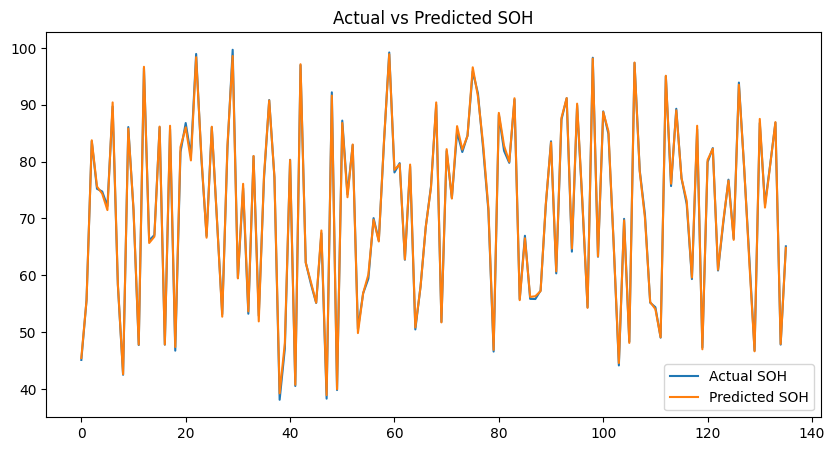

In [ ]:
# SOH COMPARISON
plt.figure(figsize=(10,5))
plt.plot(y_test['SOH'].values, label='Actual SOH')
plt.plot(predictions[:,1], label='Predicted SOH')
plt.legend()
plt.title("Actual vs Predicted SOH")
plt.show()

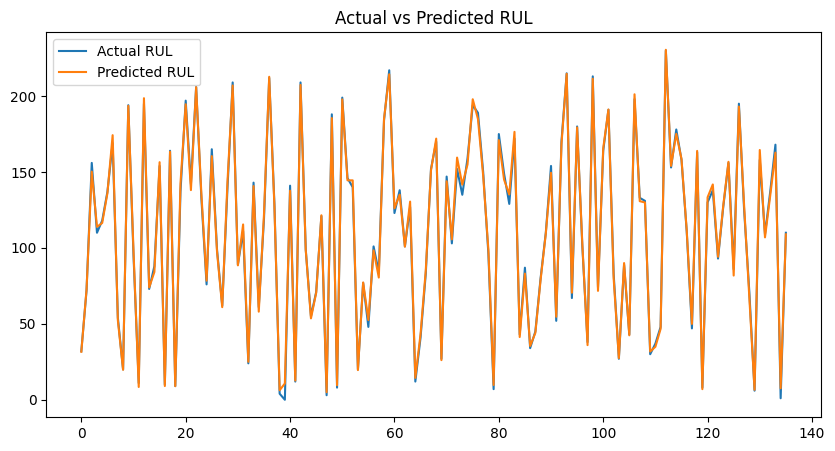

In [ ]:
# RUL COMPARISON
plt.figure(figsize=(10,5))
plt.plot(y_test['RUL'].values, label='Actual RUL')
plt.plot(predictions[:,2], label='Predicted RUL')
plt.legend()
plt.title("Actual vs Predicted RUL")
plt.show()

STEP 16 — FEATURE IMPORTANCE

In [ ]:
importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
print("FEATURE IMPORTANCE")
print(importance_df)

FEATURE IMPORTANCE
         Feature  Importance
1          cycle    0.951926
0     battery_id    0.046036
9      Temp_Diff    0.000307
10  Current_Diff    0.000264
7           disT    0.000244
8   Voltage_Diff    0.000242
6           disV    0.000223
3            chV    0.000205
2            chI    0.000194
4            chT    0.000189
5           disI    0.000170


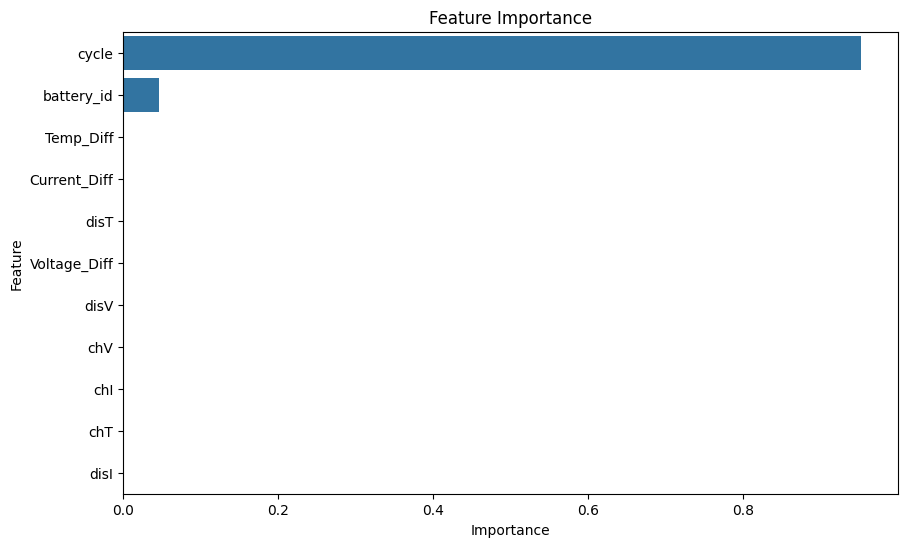

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()


STEP 17 — FINAL INSIGHTS

In [ ]:
print("FINAL PROJECT INSIGHTS")
print("""
1. Battery health decreases with increasing cycles.

2. High charging/discharging temperature
   accelerates degradation.

3. SOH and RUL are strongly related.

4. Voltage and current patterns help predict
   battery condition.

5. Random Forest successfully predicts:
   - SOH
   - RUL
   - BCt

6. Feature scaling was performed for
   professional ML workflow.

7. Outlier analysis performed using:
   - Boxplots
   - IQR Method

8. Feature engineering improved dataset quality.
""")


FINAL PROJECT INSIGHTS

1. Battery health decreases with increasing cycles.

2. High charging/discharging temperature
   accelerates degradation.

3. SOH and RUL are strongly related.

4. Voltage and current patterns help predict
   battery condition.

5. Random Forest successfully predicts:
   - SOH
   - RUL
   - BCt

6. Feature scaling was performed for
   professional ML workflow.

7. Outlier analysis performed using:
   - Boxplots
   - IQR Method

8. Feature engineering improved dataset quality.

